In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#jalar el archivo contenido en github
url = "https://raw.githubusercontent.com/isay97/temas_selectos/main/2026CO.xls"

df_raw = pd.read_excel(url)

print("Dimensiones del dataset:")
print(df_raw.shape)

df_raw.head()

Dimensiones del dataset:
(1416, 35)


,FECHA,HORA,ACO,AJM,ATI,BJU,CAM,CCA,CHO,CUA,...,SAC,SFE,SJA,TAH,TLA,TLI,UAX,UIZ,VIF,XAL
0,2026-01-01,1,-99.0,0.74,0.70,1.07,-99.0,1.12,-99,1.05,...,2.35,-99,-99,-99.0,1.15,0.89,0.75,0.94,2.17,1.66
1,2026-01-01,2,-99.0,0.55,0.78,1.03,-99.0,0.97,-99,0.95,...,2.72,-99,-99,-99.0,0.96,1.46,1.06,1.19,2.39,1.24
2,2026-01-01,3,-99.0,0.34,0.64,1.34,-99.0,0.75,-99,0.99,...,2.62,-99,-99,-99.0,0.72,1.39,1.26,1.48,2.78,1.46
3,2026-01-01,4,-99.0,0.23,0.62,1.26,-99.0,0.69,-99,1.04,...,2.77,-99,-99,-99.0,0.70,1.49,1.34,1.20,3.69,2.14
4,2026-01-01,5,-99.0,0.16,0.66,0.99,-99.0,0.69,-99,0.77,...,2.33,-99,-99,-99.0,0.53,2.04,1.45,1.58,2.67,1.89


In [5]:
#obtener informacion del archivo
print("Dimensiones:")
print(df_raw.shape)

print("\nPeriodo reportado en la columna FECHA:")
print(df_raw["FECHA"].min(), "a", df_raw["FECHA"].max())

print("\nNúmero de columnas correspondientes a estaciones:")
print(df_raw.shape[1] - 2)

Dimensiones:
(1416, 35)

Periodo reportado en la columna FECHA:
2026-01-01 00:00:00 a 2026-02-28 00:00:00

Número de columnas correspondientes a estaciones:
33


In [8]:
#preparacion de la base
estaciones = [
    col for col in df_raw.columns
    if col not in ["FECHA", "HORA"]
]

print("Número de estaciones:")
print(len(estaciones))


df = df_raw.copy()

# Sustitución de -99 por NaN

df[estaciones] = df[estaciones].replace(-99, np.nan)

# Construcción del timestamp

df["FECHA"] = pd.to_datetime(df["FECHA"],errors="coerce")

df["timestamp"] = df["FECHA"] + pd.to_timedelta(df["HORA"],unit="h")

# Orden cronológico
df = df.sort_values("timestamp").reset_index(drop=True)

# Construcción de la matriz temporal

Co_horario = df.set_index("timestamp")[estaciones].sort_index()


print("\nPrimer instante:")
print(Co_horario.index.min())

print("\nÚltimo instante:")
print(Co_horario.index.max())

print("\nNúmero de instantes horarios:")
print(len(Co_horario))

print("\nTimestamps duplicados:")
print(Co_horario.index.duplicated().sum())

print("\nFrecuencia inferida:")
print(pd.infer_freq(Co_horario.index))


# Diferencias entre instantes consecutivos
delta_t = Co_horario.index.to_series().diff()

porcentaje_horario = (
    (delta_t.dropna() == pd.Timedelta(hours=1))
    .mean() * 100
)

print("\nPorcentaje de intervalos de exactamente 1 hora:")
print(f"{porcentaje_horario:.2f}%")

# valores faltantes

print("\nNúmero total de valores faltantes:")
print(Co_horario.isna().sum().sum())

print("\nPorcentaje global de valores faltantes:")
print(f"{100 * Co_horario.isna().mean().mean():.2f}%")

Número de estaciones:
33

Primer instante:
2026-01-01 01:00:00

Último instante:
2026-03-01 00:00:00

Número de instantes horarios:
1416

Timestamps duplicados:
0

Frecuencia inferida:
h

Porcentaje de intervalos de exactamente 1 hora:
100.00%

Número total de valores faltantes:
19033

Porcentaje global de valores faltantes:
40.73%


In [10]:
#diaignostico de calidad por estacion
# Función para resumir huecos consecutivos

def resumen_huecos(serie):

    faltante = serie.isna()

    n_faltantes = int(faltante.sum())

    # Caso sin valores faltantes
    if n_faltantes == 0:
        return pd.Series({
            "n_faltantes": 0,
            "n_huecos": 0,
            "hueco_max_horas": 0
        })

    # Identificación de bloques consecutivos
    grupos = faltante.ne(faltante.shift()).cumsum()

    # Longitud de los bloques correspondientes a NaN
    longitudes = (
        faltante[faltante]
        .groupby(grupos[faltante])
        .size()
    )

    return pd.Series({
        "n_faltantes": n_faltantes,
        "n_huecos": int(len(longitudes)),
        "hueco_max_horas": int(longitudes.max())
    })


In [11]:
# Diagnóstico por estación

T = len(Co_horario)

diagnostico = pd.DataFrame({
    estacion: resumen_huecos(
        Co_horario[estacion]
    )
    for estacion in estaciones
}).T


# Número de observaciones válidas
diagnostico["n_disponibles"] = Co_horario.notna().sum()


# Número esperado
diagnostico["n_esperadas"] = T


# Cobertura
diagnostico["cobertura_pct"] = (
    diagnostico["n_disponibles"]
    / diagnostico["n_esperadas"]
    * 100
)


# Hueco máximo expresado en días
diagnostico["hueco_max_dias"] = (
    diagnostico["hueco_max_horas"] / 24
)


# Reordenamos columnas
diagnostico = diagnostico[
    [
        "n_esperadas",
        "n_disponibles",
        "n_faltantes",
        "cobertura_pct",
        "n_huecos",
        "hueco_max_horas",
        "hueco_max_dias"
    ]
]


# Ordenamos de mayor a menor cobertura
diagnostico = diagnostico.sort_values("cobertura_pct",ascending=False)


print("Diagnóstico de calidad por estación:")

display(diagnostico.round(2))


print("\nResumen de cobertura:")

display(
    diagnostico["cobertura_pct"]
    .describe().round(2).to_frame("cobertura_pct")
)

Diagnóstico de calidad por estación:


,n_esperadas,n_disponibles,n_faltantes,cobertura_pct,n_huecos,hueco_max_horas,hueco_max_dias
CUT,1416,1396,20,98.59,7,5,0.21
TLA,1416,1385,31,97.81,10,4,0.17
PED,1416,1385,31,97.81,11,6,0.25
MGH,1416,1382,34,97.60,11,4,0.17
HGM,1416,1379,37,97.39,13,5,0.21
FAC,1416,1379,37,97.39,14,4,0.17
AJM,1416,1374,42,97.03,18,4,0.17
MER,1416,1361,55,96.12,16,14,0.58
UAX,1416,1356,60,95.76,11,30,1.25
VIF,1416,1331,85,94.00,19,32,1.33



Resumen de cobertura:


,cobertura_pct
count,33.00
mean,59.27
std,38.91
min,0.00
25%,30.23
50%,77.61
75%,95.76
max,98.59


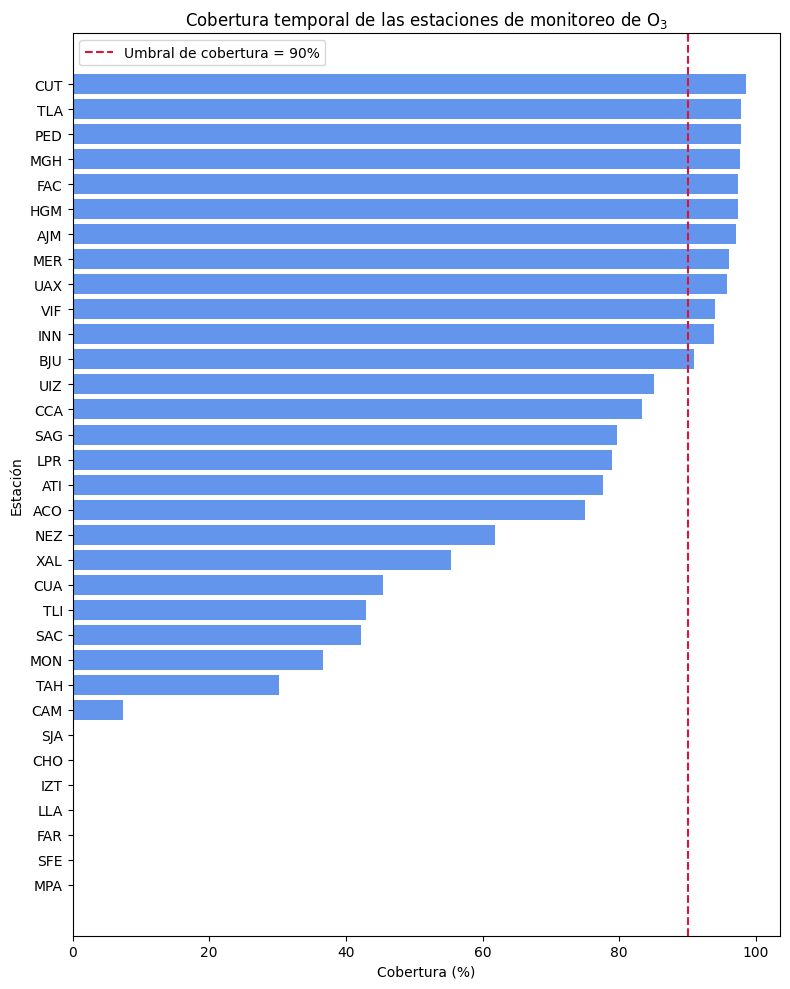

Estaciones con cobertura >= 90%: 12 de 33


In [12]:
# Visualización de la cobertura por estación

cobertura_ordenada = (
    diagnostico["cobertura_pct"]
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 10))

ax.barh(
    cobertura_ordenada.index,
    cobertura_ordenada.values, color='cornflowerblue'
)

ax.axvline(x=90, linestyle="--", linewidth=1.5,
    label="Umbral de cobertura = 90%", color='crimson'
)

ax.set_title("Cobertura temporal de las estaciones de monitoreo de O$_3$")

ax.set_xlabel("Cobertura (%)")
ax.set_ylabel("Estación")


ax.legend()
plt.tight_layout()
plt.savefig("cobertura_estaciones.png", dpi=200)
plt.show()

# Número de estaciones que cumplen el criterio
n_seleccionadas = (diagnostico["cobertura_pct"] >= 90).sum()

print(f"Estaciones con cobertura >= 90%: "
    f"{n_seleccionadas} de {len(diagnostico)}")

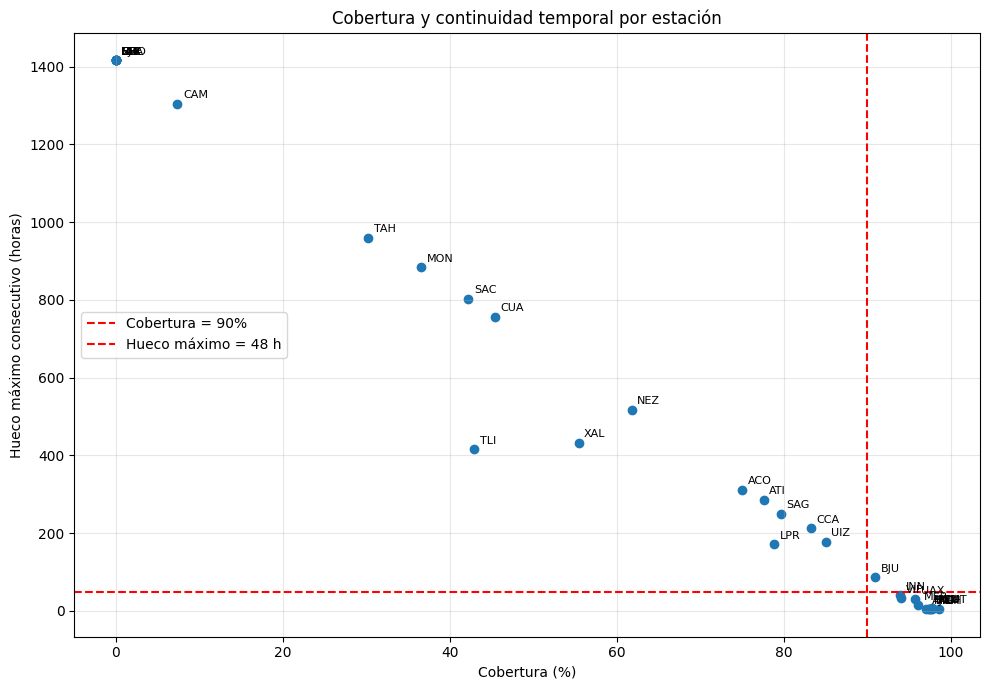

In [13]:
# Cobertura vs. hueco temporal máximo

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    diagnostico["cobertura_pct"],
    diagnostico["hueco_max_horas"]
)

# Etiquetas de estaciones
for estacion, fila in diagnostico.iterrows():
    ax.annotate(
        estacion,
        (
            fila["cobertura_pct"],
            fila["hueco_max_horas"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )


ax.axvline(
    90,
    linestyle="--",
    linewidth=1.5,
    label="Cobertura = 90%", color ='red'
)

ax.axhline(
    48,
    linestyle="--",
    linewidth=1.5,
    label="Hueco máximo = 48 h", color ='red'
)


ax.set_title(
    "Cobertura y continuidad temporal por estación"
)

ax.set_xlabel("Cobertura (%)")
ax.set_ylabel("Hueco máximo consecutivo (horas)")

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Estaciones que cumplen ambos criterios

criterio_cobertura = (
    diagnostico["cobertura_pct"] >= 90
)

criterio_hueco = (
    diagnostico["hueco_max_horas"] <= 48
)

candidatas = diagnostico[
    criterio_cobertura & criterio_hueco].copy()


print("Estaciones que cumplen ambos criterios:")
print(candidatas.index.tolist())

print("\nNúmero de estaciones:")
print(len(candidatas))

display(
    candidatas[
        [
            "cobertura_pct",
            "n_faltantes",
            "n_huecos",
            "hueco_max_horas",
            "hueco_max_dias"
        ]
    ].round(2)
)

Estaciones que cumplen ambos criterios:
['CUT', 'TLA', 'PED', 'MGH', 'HGM', 'FAC', 'AJM', 'MER', 'UAX', 'VIF', 'INN']

Número de estaciones:
11


,cobertura_pct,n_faltantes,n_huecos,hueco_max_horas,hueco_max_dias
CUT,98.59,20,7,5,0.21
TLA,97.81,31,10,4,0.17
PED,97.81,31,11,6,0.25
MGH,97.60,34,11,4,0.17
HGM,97.39,37,13,5,0.21
FAC,97.39,37,14,4,0.17
AJM,97.03,42,18,4,0.17
MER,96.12,55,16,14,0.58
UAX,95.76,60,11,30,1.25
VIF,94.00,85,19,32,1.33


In [17]:
# Construcción del panel en formato ancho

estaciones_finales = candidatas.index.tolist()

Co_seleccionado = Co_horario[estaciones_finales].copy()
Co_seleccionado

,CUT,TLA,PED,MGH,HGM,FAC,AJM,MER,UAX,VIF,INN
timestamp,,,,,,,,,,,
2026-01-01 01:00:00,0.80,1.15,1.06,0.75,0.93,0.72,0.74,1.05,0.75,2.17,0.46
2026-01-01 02:00:00,0.96,0.96,0.60,0.67,0.96,0.71,0.55,1.31,1.06,2.39,0.26
2026-01-01 03:00:00,0.78,0.72,0.44,0.81,1.18,0.82,0.34,1.63,1.26,2.78,0.16
2026-01-01 04:00:00,0.78,0.70,0.36,1.25,1.98,0.74,0.23,1.43,1.34,3.69,0.14
2026-01-01 05:00:00,0.62,0.53,0.27,1.16,1.50,0.82,0.16,1.22,1.45,2.67,0.10
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 20:00:00,0.39,0.32,0.21,0.34,0.37,0.35,0.29,0.36,0.44,0.35,0.20
2026-02-28 21:00:00,0.47,0.45,0.25,0.40,0.39,0.50,0.34,0.40,0.43,0.49,0.22
2026-02-28 22:00:00,0.60,0.54,0.36,0.47,0.50,0.84,0.49,0.55,0.56,0.69,0.30


In [18]:
# Faltantes después de la selección

n_total = Co_seleccionado.size
n_faltantes = Co_seleccionado.isna().sum().sum()

print("\nNúmero total de valores posibles:")
print(n_total)

print("\nNúmero total de valores faltantes:")
print(n_faltantes)

print("\nPorcentaje global de faltantes:")
print(
    f"{100 * n_faltantes / n_total:.2f}%"
)


Número total de valores posibles:
15576

Número total de valores faltantes:
518

Porcentaje global de faltantes:
3.33%


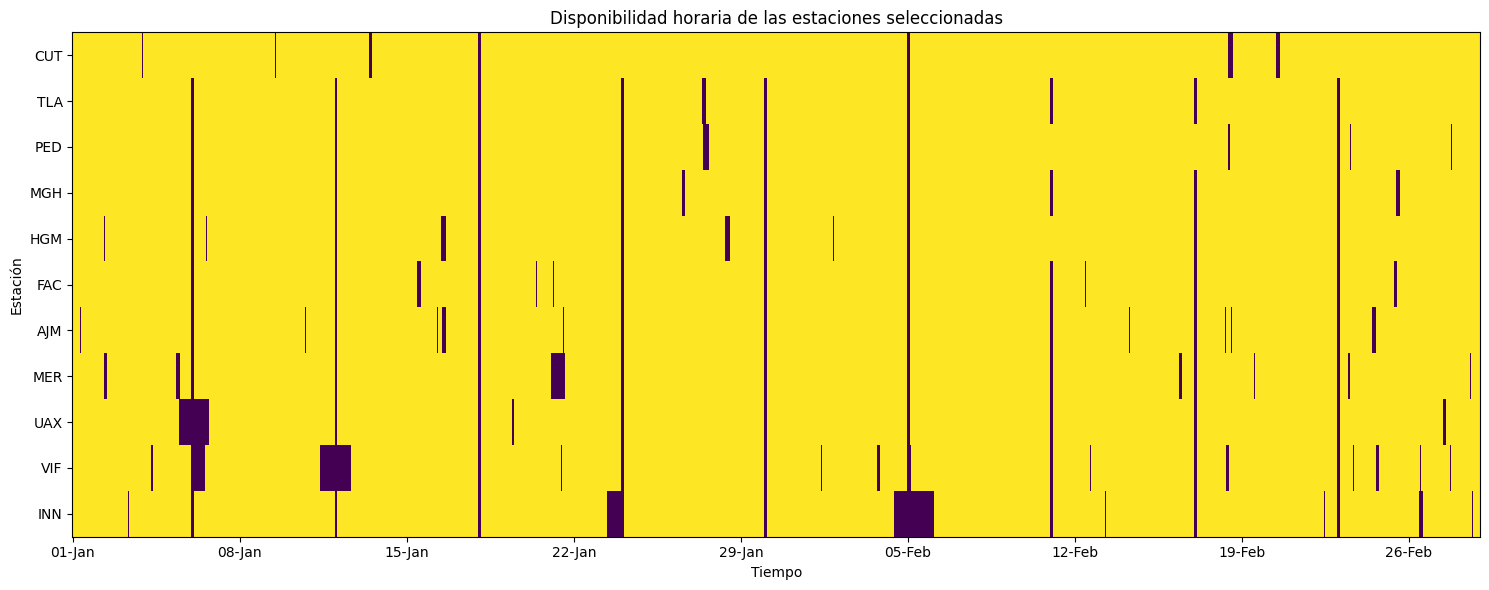

In [19]:
# Matriz de disponibilidad

matriz_disponibilidad = Co_seleccionado.notna().astype(int).T


fig, ax = plt.subplots(figsize=(15, 6))

ax.imshow(
    matriz_disponibilidad,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title("Disponibilidad horaria de las estaciones seleccionadas")
ax.set_ylabel("Estación")
ax.set_xlabel("Tiempo")

ax.set_yticks(np.arange(len(estaciones_finales)))
ax.set_yticklabels(estaciones_finales)


paso = 24 * 7

posiciones = np.arange(0,len(Co_seleccionado),paso)
etiquetas = Co_seleccionado.index[posiciones].strftime("%d-%b")

ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas)

plt.tight_layout()
plt.show()

Disponibilidad simultánea del panel seleccionado
Después de seleccionar las
 12 estaciones, el porcentaje global de valores faltantes disminuyó considerablemente 3.33%:
 Sin embargo, este porcentaje resume toda la matriz y no indica si los faltantes se encuentran distribuidos de manera independiente entre estaciones o si existen horas en las que varias estaciones dejan de reportar simultáneamente.

In [21]:
# Disponibilidad simultánea del panel seleccionado

disponibilidad_panel = pd.DataFrame(
    index=Co_seleccionado.index
)

disponibilidad_panel["n_disponibles"] = (
    Co_seleccionado.notna().sum(axis=1)
)

disponibilidad_panel["porcentaje_disponible"] = (
    disponibilidad_panel["n_disponibles"]
    / len(estaciones_finales) * 100
)


print("Resumen del número de estaciones disponibles por hora:")

display(disponibilidad_panel["n_disponibles"].describe().round(2).to_frame())


# Horas completamente observadas
n_completas = (
    disponibilidad_panel["n_disponibles"]
    == len(estaciones_finales)
).sum()

print("\nHoras con las 12 estaciones disponibles:")
print(n_completas)
print(f"Porcentaje: "f"{100 * n_completas / len(disponibilidad_panel):.2f}%")


# Horas sin ninguna estación disponible
n_sin_datos = (
    disponibilidad_panel["n_disponibles"] == 0
).sum()

print("\nHoras sin ninguna estación disponible:")
print(n_sin_datos)

print(f"Porcentaje: "f"{100 * n_sin_datos / len(disponibilidad_panel):.2f}%")


# Distribución de disponibilidad
print("\nNúmero de horas según estaciones disponibles:")

display(
    disponibilidad_panel["n_disponibles"]
    .value_counts().sort_index(ascending=False).rename("n_horas").to_frame()
)

Resumen del número de estaciones disponibles por hora:


,n_disponibles
count,1416.00
mean,10.63
std,1.40
min,0.00
25%,11.00
50%,11.00
75%,11.00
max,11.00



Horas con las 12 estaciones disponibles:
1169
Porcentaje: 82.56%

Horas sin ninguna estación disponible:
6
Porcentaje: 0.42%

Número de horas según estaciones disponibles:


,n_horas
n_disponibles,
11,1169
10,190
9,29
8,1
3,3
2,3
1,15
0,6


In [22]:
# Horas con menos del 50% de las estaciones disponibles

umbral_simultaneo = 50

horas_baja_disponibilidad = disponibilidad_panel[
    disponibilidad_panel["porcentaje_disponible"]
    < umbral_simultaneo
]

print(f"\nHoras con disponibilidad < {umbral_simultaneo}%:")

print(len(horas_baja_disponibilidad))

display(horas_baja_disponibilidad)


Horas con disponibilidad < 50%:
27


,n_disponibles,porcentaje_disponible
timestamp,,
2026-01-06 01:00:00,1,9.090909
2026-01-06 02:00:00,1,9.090909
2026-01-06 03:00:00,1,9.090909
2026-01-12 01:00:00,1,9.090909
2026-01-12 02:00:00,1,9.090909
2026-01-12 03:00:00,1,9.090909
2026-01-18 01:00:00,0,0.000000
2026-01-18 02:00:00,0,0.000000
2026-01-18 03:00:00,0,0.000000


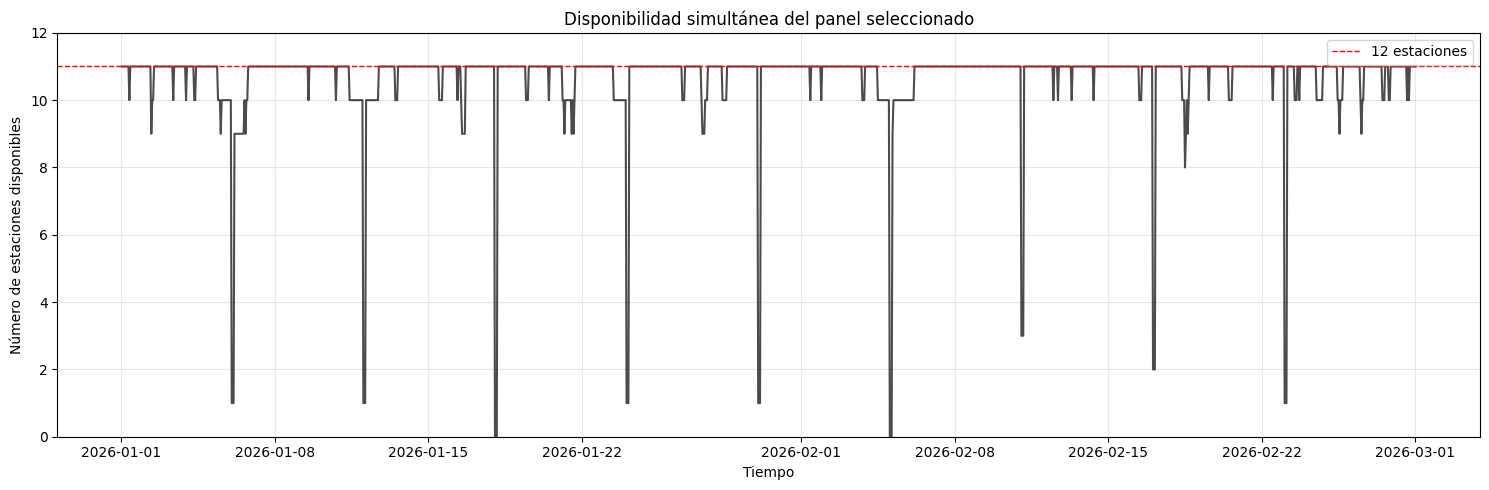

In [24]:
# Evolución temporal

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    disponibilidad_panel.index,
    disponibilidad_panel["n_disponibles"], color ='black', alpha=0.7
)

ax.axhline(len(estaciones_finales),linestyle="--",
    linewidth=1,label="12 estaciones", color='red'
)

ax.set_title("Disponibilidad simultánea del panel seleccionado")

ax.set_xlabel("Tiempo")
ax.set_ylabel("Número de estaciones disponibles")
ax.set_ylim(0,len(estaciones_finales) + 1)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Identificación de interrupciones colectivas de la red
La selección de estaciones redujo considerablemente la proporción de valores faltantes, pero todavía existen horas en las que gran parte de la red deja de reportar simultáneamente.

**pt= porcentaje de las estaciones**

In [25]:
# Identificación de horas de baja disponibilidad

umbral_disponibilidad = 50

disponibilidad_panel["baja_disponibilidad"] = (
    disponibilidad_panel["porcentaje_disponible"]
    < umbral_disponibilidad
)


# Agrupación de horas consecutivas en episodios

grupos = (
    disponibilidad_panel["baja_disponibilidad"]
    .ne(
        disponibilidad_panel["baja_disponibilidad"].shift()
    )
    .cumsum()
)

episodios = []

for _, bloque in disponibilidad_panel[
    disponibilidad_panel["baja_disponibilidad"]
].groupby(
    grupos[disponibilidad_panel["baja_disponibilidad"]]
):

    episodios.append({
        "inicio": bloque.index.min(),
        "fin": bloque.index.max(),
        "duracion_horas": len(bloque),
        "min_estaciones": bloque["n_disponibles"].min(),
        "min_porcentaje": bloque["porcentaje_disponible"].min()
    })


episodios_red = pd.DataFrame(episodios)


# Tiempo entre episodios

episodios_red["horas_desde_anterior"] = (
    episodios_red["inicio"]
    .diff()
    .dt.total_seconds()
    / 3600
)

episodios_red["dias_desde_anterior"] = (
    episodios_red["horas_desde_anterior"]
    / 24
)

In [26]:
print("Número de episodios de baja disponibilidad:")
print(len(episodios_red))

print("\nEpisodios detectados:")

display(episodios_red.round(2))


print("\nDuración total de las horas de baja disponibilidad:")
print(episodios_red["duracion_horas"].sum(),"horas")


print("\nIntervalos entre inicios de episodios:")

display(episodios_red[["inicio","dias_desde_anterior"]])

Número de episodios de baja disponibilidad:
9

Episodios detectados:


,inicio,fin,duracion_horas,min_estaciones,min_porcentaje,horas_desde_anterior,dias_desde_anterior
0,2026-01-06 01:00:00,2026-01-06 03:00:00,3,1,9.09,NaN,NaN
1,2026-01-12 01:00:00,2026-01-12 03:00:00,3,1,9.09,144.0,6.0
2,2026-01-18 01:00:00,2026-01-18 03:00:00,3,0,0.00,144.0,6.0
3,2026-01-24 01:00:00,2026-01-24 03:00:00,3,1,9.09,144.0,6.0
4,2026-01-30 01:00:00,2026-01-30 03:00:00,3,1,9.09,144.0,6.0
5,2026-02-05 01:00:00,2026-02-05 03:00:00,3,0,0.00,144.0,6.0
6,2026-02-11 01:00:00,2026-02-11 03:00:00,3,3,27.27,144.0,6.0
7,2026-02-17 01:00:00,2026-02-17 03:00:00,3,2,18.18,144.0,6.0
8,2026-02-23 01:00:00,2026-02-23 03:00:00,3,1,9.09,144.0,6.0



Duración total de las horas de baja disponibilidad:
27 horas

Intervalos entre inicios de episodios:


,inicio,dias_desde_anterior
0,2026-01-06 01:00:00,NaN
1,2026-01-12 01:00:00,6.0
2,2026-01-18 01:00:00,6.0
3,2026-01-24 01:00:00,6.0
4,2026-01-30 01:00:00,6.0
5,2026-02-05 01:00:00,6.0
6,2026-02-11 01:00:00,6.0
7,2026-02-17 01:00:00,6.0
8,2026-02-23 01:00:00,6.0


El diagnóstico también mostró que existen dos tipos diferentes de ausencia de información:

faltantes individuales o pequeños huecos en una estación;
episodios de baja disponibilidad en los que muchas estaciones dejan de reportar simultáneamente.
Por esta razón utilizaremos una estrategia de imputación en dos etapas.

1. Interpolación temporal para huecos cortos
Para observaciones faltantes fuera de los episodios de baja disponibilidad utilizaremos interpolación temporal.

La idea consiste en estimar un valor intermedio utilizando las observaciones vecinas de la misma estación.

Limitaremos la interpolación a huecos pequeños para evitar reconstruir artificialmente interrupciones prolongadas.

2. Perfil horario para los valores restantes
Los valores que continúen faltantes se sustituirán utilizando la mediana de la misma estación para la misma hora del día.


In [28]:
# Máscara de valores originalmente faltantes

mascara_imputados = Co_seleccionado.isna().copy()

print("Valores faltantes antes de imputar:")
print(mascara_imputados.sum().sum())



Co_imputado = Co_seleccionado.copy()


# ETAPA 1: Interpolación temporal de huecos cortos

interpolado = Co_seleccionado.interpolate(
    method="time",
    limit=3,
    limit_direction="both",
    limit_area="inside"
)

# No utilizaremos interpolación durante los episodios de baja disponibilidad de la red
horas_problematicas = (
    disponibilidad_panel["baja_disponibilidad"]
)

for estacion in estaciones_finales:

    usar_interpolacion = (
        Co_seleccionado[estacion].isna()
        & ~horas_problematicas
    )

    Co_imputado.loc[
        usar_interpolacion,
        estacion
    ] = interpolado.loc[
        usar_interpolacion,
        estacion
    ]


print("\nFaltantes después de la interpolación:")
print(Co_imputado.isna().sum().sum())


# ETAPA 2: Mediana de cada estación según la hora del día

for estacion in estaciones_finales:

    # Perfil horario calculado únicamente con datos originales
    mediana_horaria = (
        Co_seleccionado[estacion]
        .groupby(Co_seleccionado.index.hour)
        .median()
    )

    faltantes = Co_imputado[estacion].isna()

    horas = Co_imputado.index[faltantes].hour

    Co_imputado.loc[faltantes, estacion] = (
        horas.map(mediana_horaria)
    )



# Verificación

print("\nFaltantes después de las dos etapas:")
print(Co_imputado.isna().sum().sum())

print("\nNúmero de valores originalmente faltantes:")
print(mascara_imputados.sum().sum())

print("\nPorcentaje de valores imputados:")
print(
    f"{100 * mascara_imputados.sum().sum() / Co_imputado.size:.2f}%"
)

print("\nDimensiones del panel:")
print(Co_imputado.shape)

print("\nFrecuencia temporal:")
print(pd.infer_freq(Co_imputado.index))

Valores faltantes antes de imputar:
518

Faltantes después de la interpolación:
369

Faltantes después de las dos etapas:
0

Número de valores originalmente faltantes:
518

Porcentaje de valores imputados:
3.33%

Dimensiones del panel:
(1416, 11)

Frecuencia temporal:
h


**Distribución de las concentraciones de ozono en las estaciones seleccionadas**

Una vez construido el panel completo podemos comparar el comportamiento de las concentraciones de ozono entre estaciones.

Para cada estación analizaremos:

mediana;
rango intercuartílico;
dispersión;
concentraciones elevadas.
Utilizaremos diagramas de caja, ya que permiten comparar simultáneamente las distribuciones de las
12 estaciones.

In [29]:
# Estadísticos descriptivos

resumen_Co = (
    Co_imputado.describe().T
    .rename(columns={
        "count": "n",
        "mean": "media",
        "std": "desv_std",
        "min": "minimo",
        "25%": "q25",
        "50%": "mediana",
        "75%": "q75",
        "max": "maximo"
    })
)

resumen_Co["IQR"] = resumen_Co["q75"] - resumen_Co["q25"]

resumen_Co = resumen_Co.sort_values("mediana", ascending=False)

print("Resumen de las concentraciones por estación:")
resumen_Co[["media","mediana","desv_std","q25","q75","IQR","maximo"]].round(2)

Resumen de las concentraciones por estación:


,media,mediana,desv_std,q25,q75,IQR,maximo
MER,1.08,0.92,0.55,0.69,1.37,0.68,3.72
HGM,0.83,0.67,0.55,0.41,1.12,0.71,3.15
UAX,0.73,0.67,0.38,0.44,0.93,0.49,2.53
VIF,0.83,0.66,0.62,0.36,1.11,0.75,3.69
TLA,0.71,0.56,0.47,0.39,0.84,0.45,3.20
MGH,0.72,0.54,0.50,0.37,0.92,0.55,2.85
PED,0.58,0.52,0.36,0.32,0.77,0.45,2.60
FAC,0.77,0.51,0.66,0.36,0.90,0.54,5.16
CUT,0.57,0.46,0.42,0.28,0.74,0.46,2.79
AJM,0.46,0.41,0.26,0.27,0.58,0.31,1.66


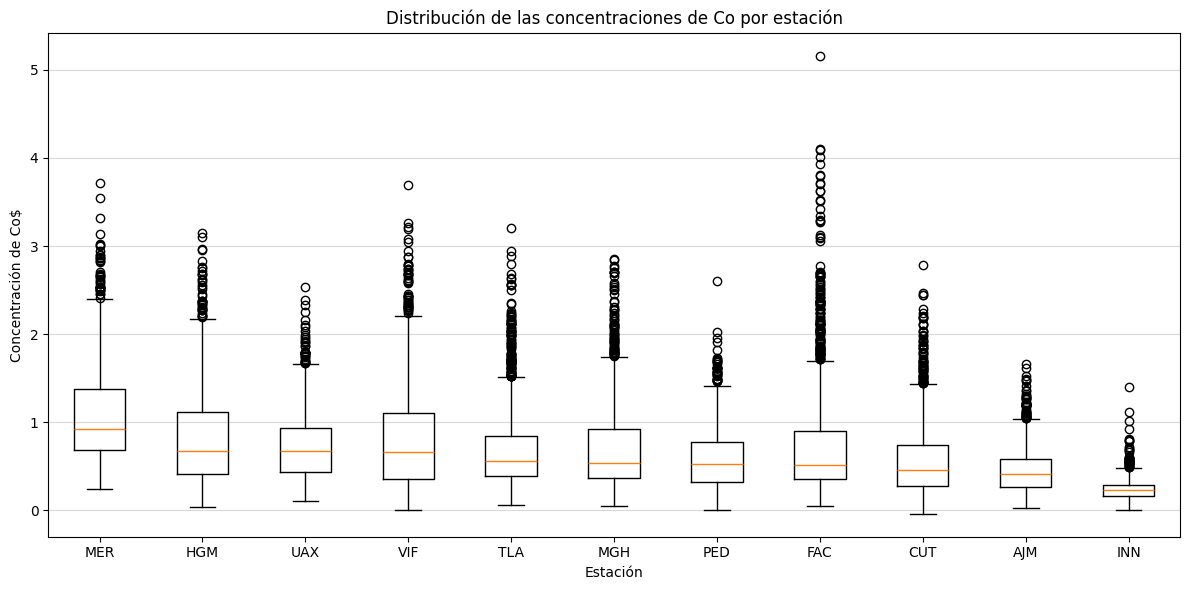

In [31]:
orden = resumen_Co.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot([Co_imputado[e] for e in orden],
    tick_labels=orden,
    showfliers=True)

ax.set_title("Distribución de las concentraciones de Co por estación")
ax.set_xlabel("Estación")
ax.set_ylabel("Concentración de Co$")
ax.tick_params(axis="x")
ax.grid(axis="y",alpha=0.5)

plt.tight_layout()
plt.show()

**Patrón intradiario de las concentraciones de ozono**

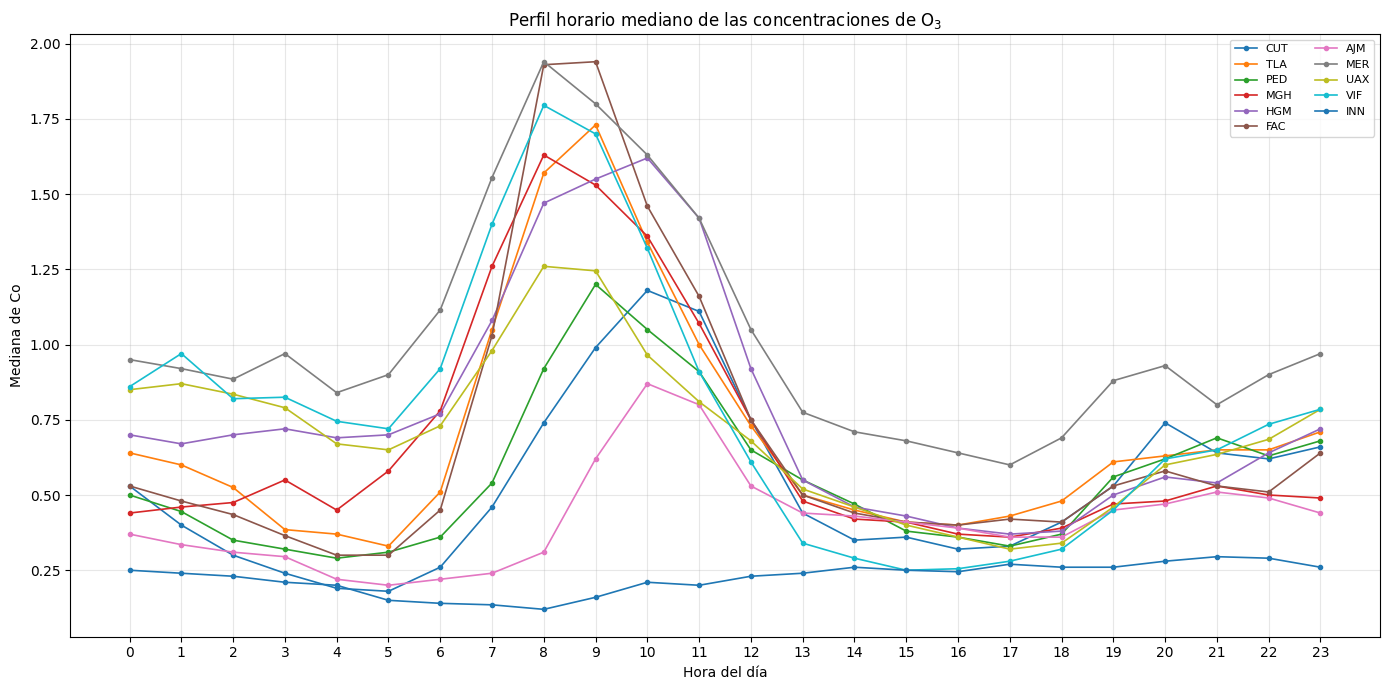

In [32]:
# Perfil horario mediano

perfil_horario = (
    Co_imputado
    .groupby(Co_imputado.index.hour)
    .median()
)

perfil_horario.index.name = "hora"


fig, ax = plt.subplots(figsize=(14, 7))

for estacion in estaciones_finales:

    ax.plot(
        perfil_horario.index,
        perfil_horario[estacion],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=estacion
    )

ax.set_title(
    "Perfil horario mediano de las concentraciones de O$_3$"
)

ax.set_xlabel("Hora del día")
ax.set_ylabel("Mediana de Co")

ax.set_xticks(range(24))

ax.grid(alpha=0.3)

ax.legend(
    ncol=2,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [33]:
# Hora del máximo típico por estación

resumen_horario = pd.DataFrame({
    "hora_maxima": perfil_horario.idxmax(),
    "valor_mediano_maximo": perfil_horario.max()
})

print("Hora del máximo mediano por estación:")
resumen_horario.sort_values("hora_maxima").round(2)

Hora del máximo mediano por estación:


,hora_maxima,valor_mediano_maximo
MGH,8,1.63
MER,8,1.94
VIF,8,1.80
UAX,8,1.26
FAC,9,1.94
TLA,9,1.73
PED,9,1.20
CUT,10,1.18
AJM,10,0.87
HGM,10,1.62


In [34]:
# Promedio diario por estación

# Desplazamos una hora para recuperar la convención original de días con horas 1,...,24
Co_para_diario = Co_imputado.copy()

Co_para_diario.index = Co_para_diario.index - pd.Timedelta(hours=1)

# Promedio diario
Co_diario = Co_para_diario.resample("D").mean()


print("Dimensiones de la base horaria:")
print(Co_imputado.shape)

print("\nDimensiones de la base diaria:")
print(Co_diario.shape)

print("\nPeriodo:")
print(
    Co_diario.index.min(),
    "a",
    Co_diario.index.max()
)

print("\nPrimeros promedios diarios:")
display(Co_diario.head())

Dimensiones de la base horaria:
(1416, 11)

Dimensiones de la base diaria:
(59, 11)

Periodo:
2026-01-01 00:00:00 a 2026-02-28 00:00:00

Primeros promedios diarios:


,CUT,TLA,PED,MGH,HGM,FAC,AJM,MER,UAX,VIF,INN
timestamp,,,,,,,,,,,
2026-01-01,0.494167,0.536250,0.435417,0.743333,0.878333,0.554167,0.333958,0.995000,0.850417,1.399583,0.225417
2026-01-02,0.516250,0.689167,0.433750,0.630417,0.981667,0.713333,0.295417,1.334583,0.574167,0.919167,0.142083
2026-01-03,0.481042,0.564583,0.420000,0.691250,1.037083,0.529167,0.290417,1.318750,0.691250,0.871667,0.165417
2026-01-04,0.804583,0.593750,0.420833,0.672083,0.887083,0.648750,0.277083,1.228750,0.630833,0.705833,0.209167
2026-01-05,0.999167,0.984167,0.654583,1.010000,1.352500,1.120000,0.429583,1.682917,0.756794,1.121667,0.283750


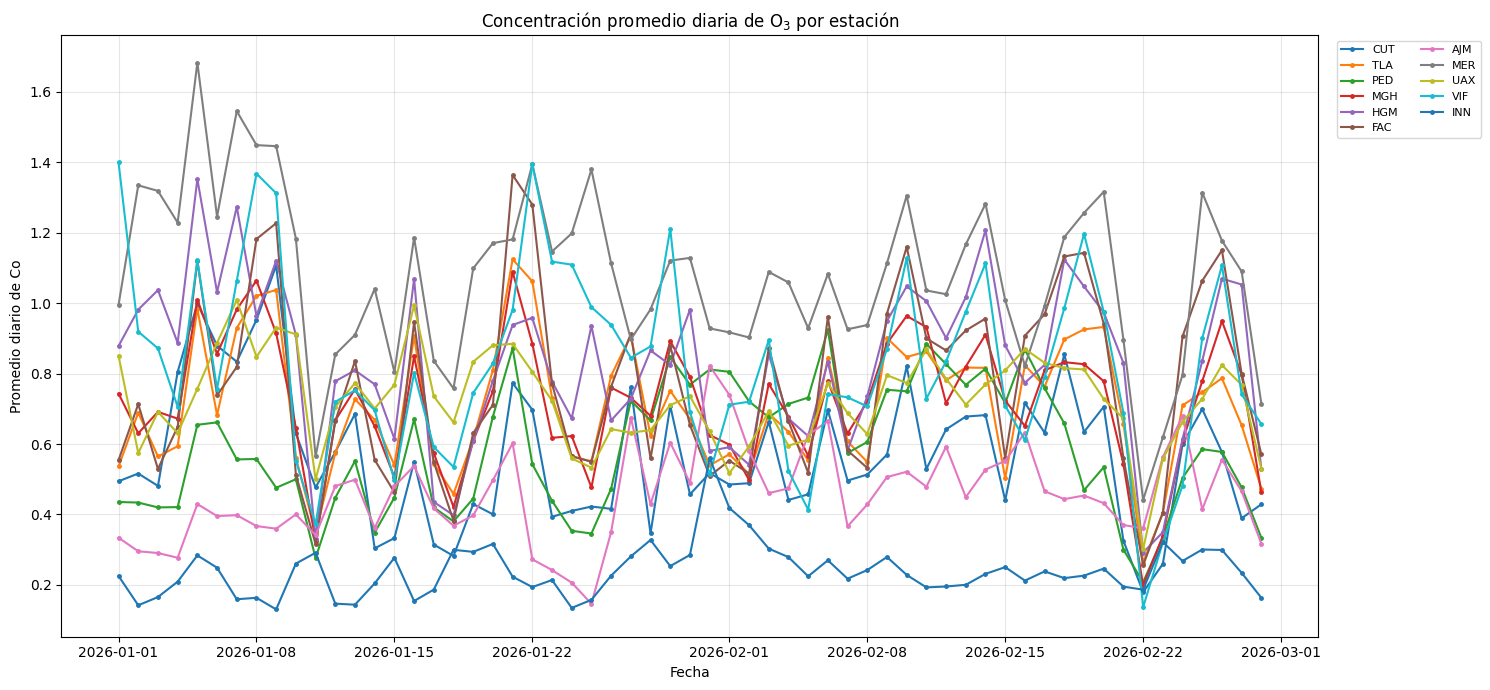

In [36]:
fig, ax = plt.subplots(figsize=(15, 7))

for estacion in estaciones_finales:

    ax.plot(
        Co_diario.index,
        Co_diario[estacion],
        linewidth=1.5,
        marker="o",
        markersize=2.5,
        label=estacion)


ax.set_title("Concentración promedio diaria de O$_3$ por estación")

ax.set_xlabel("Fecha")
ax.set_ylabel("Promedio diario de Co")
ax.grid(alpha=0.3)
ax.legend(
    ncol=2,
    fontsize=8,
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Promedio diario de ozono de la red seleccionada**

Para resumir el comportamiento global de las estaciones seleccionadas podemos calcular, para cada día, el promedio de las concentraciones medias diarias de las
12 estaciones.

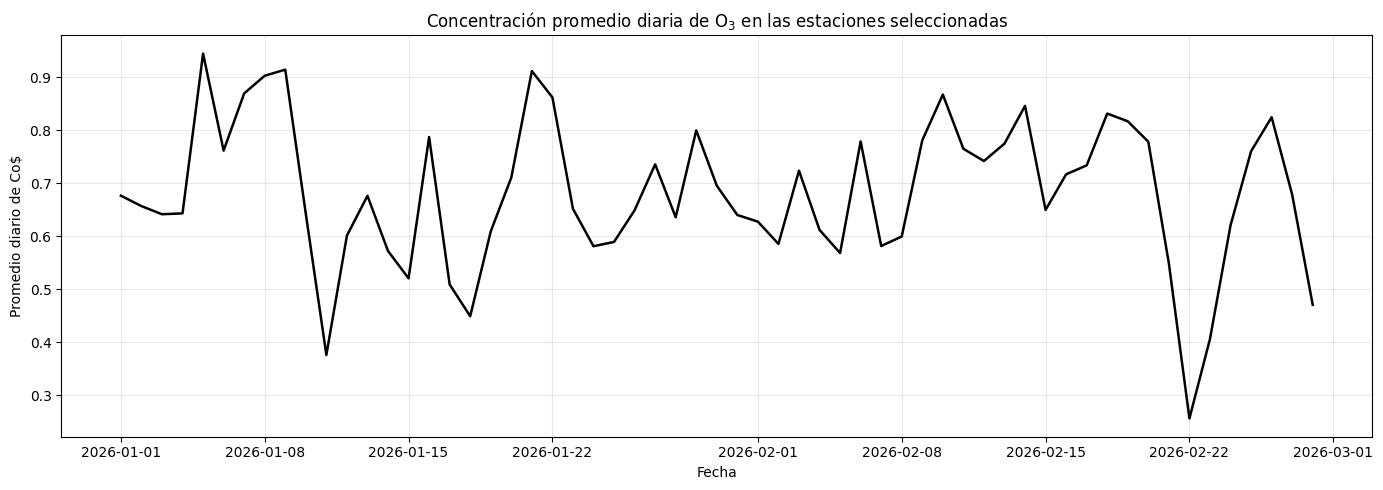

In [38]:
# Promedio diario de todas las estaciones

promedio_diario_red = Co_diario.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    promedio_diario_red.index,
    promedio_diario_red,
    markersize=4,
    linewidth=1.8, color = 'black'
)

ax.set_title("Concentración promedio diaria de O$_3$ en las estaciones seleccionadas")
ax.set_xlabel("Fecha")
ax.set_ylabel("Promedio diario de Co$")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [39]:
print("Resumen del promedio diario de la red:")
display(promedio_diario_red.describe().round(2).to_frame("o3_promedio_diario"))

print("\nDía con mayor promedio:")
print(promedio_diario_red.idxmax())

print("Valor:")
print(round(promedio_diario_red.max(), 2))

print("\nDía con menor promedio:")
print(promedio_diario_red.idxmin())

print("Valor:")
print(round(promedio_diario_red.min(), 2))

Resumen del promedio diario de la red:


,o3_promedio_diario
count,59.00
mean,0.68
std,0.14
min,0.26
25%,0.60
50%,0.68
75%,0.78
max,0.95



Día con mayor promedio:
2026-01-05 00:00:00
Valor:
0.95

Día con menor promedio:
2026-02-22 00:00:00
Valor:
0.26


In [43]:
# Panel de concentraciones de O3

panel_Co = (
    Co_imputado
    .reset_index()
    .melt(
        id_vars="timestamp",
        var_name="estacion",
        value_name="Co"
    )
)


# Indicador de valores imputados

panel_imp = (
    mascara_imputados
    .reset_index()
    .melt(
        id_vars="timestamp",
        var_name="estacion",
        value_name="imputado"
    )
)


# Integración

panel_final = panel_Co.merge(
    panel_imp,
    on=["timestamp", "estacion"],
    how="left"
)


# Bandera de baja disponibilidad de la red

panel_final["baja_disponibilidad"] = (
    panel_final["timestamp"]
    .map(
        disponibilidad_panel["baja_disponibilidad"]
    )
)


# Recuperamos la convención temporal original
# FECHA + HORA = 1,...,24

tiempo_fuente = (
    panel_final["timestamp"]
    - pd.Timedelta(hours=1)
)

panel_final["fecha"] = (
    tiempo_fuente.dt.normalize()
)

panel_final["hora"] = (
    ((panel_final["timestamp"].dt.hour - 1) % 24) + 1
)


# Reordenamos columnas

panel_final = panel_final[
    [
        "timestamp",
        "fecha",
        "hora",
        "estacion",
        "Co",
        "imputado",
        "baja_disponibilidad"
    ]
]


# Orden estación-tiempo
panel_final = (
    panel_final
    .sort_values(
        ["estacion", "timestamp"]
    )
    .reset_index(drop=True)
)


print("Dimensiones del panel final:")
print(panel_final.shape)

print("\nNúmero de estaciones:")
print(panel_final["estacion"].nunique())

print("\nNúmero de instantes temporales:")
print(panel_final["timestamp"].nunique())

print("\nValores faltantes en Co:")
print(panel_final["Co"].isna().sum())

print("\nObservaciones imputadas:")
print(panel_final["imputado"].sum())

print("\nObservaciones en periodos de baja disponibilidad:")
print(panel_final["baja_disponibilidad"].sum())

print("\nCombinaciones estación-timestamp duplicadas:")
print(panel_final.duplicated(subset=["estacion", "timestamp"]).sum())

Dimensiones del panel final:
(15576, 7)

Número de estaciones:
11

Número de instantes temporales:
1416

Valores faltantes en Co:
0

Observaciones imputadas:
518

Observaciones en periodos de baja disponibilidad:
297

Combinaciones estación-timestamp duplicadas:
0


In [45]:
print("\nPrimeras observaciones:")
display(panel_final.head(15))


# Guardado
nombre_archivo = "panel_Co_2026.csv"

panel_final.to_csv(
    nombre_archivo,
    index=False
)

print("\nPanel guardado como:")
print(nombre_archivo)


Primeras observaciones:


,timestamp,fecha,hora,estacion,Co,imputado,baja_disponibilidad
0,2026-01-01 01:00:00,2026-01-01,1,AJM,0.740,False,False
1,2026-01-01 02:00:00,2026-01-01,2,AJM,0.550,False,False
2,2026-01-01 03:00:00,2026-01-01,3,AJM,0.340,False,False
3,2026-01-01 04:00:00,2026-01-01,4,AJM,0.230,False,False
4,2026-01-01 05:00:00,2026-01-01,5,AJM,0.160,False,False
5,2026-01-01 06:00:00,2026-01-01,6,AJM,0.160,False,False
6,2026-01-01 07:00:00,2026-01-01,7,AJM,0.140,False,False
7,2026-01-01 08:00:00,2026-01-01,8,AJM,0.110,False,False
8,2026-01-01 09:00:00,2026-01-01,9,AJM,0.445,True,False
9,2026-01-01 10:00:00,2026-01-01,10,AJM,0.780,False,False



Panel guardado como:
panel_Co_2026.csv
